# 03 — Exploratory Data Analysis

## Research Question

**What product attributes are associated with consumer satisfaction in the Smart TV market, and how are major brands positioned relative to competitors?**

This notebook explores the 2015–2023 Smart TV dataset across five brands: Samsung, LG, Sony, TCL, and Hisense.

The analysis examines:
- Brand representation and customer rating distributions
- Review-weighted versus product-weighted satisfaction
- Review concentration across products
- Product attributes, including screen size, resolution, and display technology
- Associations between product attributes and customer ratings

These findings provide context for the consumer review analysis and competitive positioning developed in the following notebooks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [3]:
products = pd.read_parquet(
    "../data/tv_products_clean.parquet"
)

reviews = pd.read_parquet(
    "../data/tv_reviews_clean.parquet"
)

print("Products:", products.shape)
print("Reviews:", reviews.shape)

Products: (1097, 16)
Reviews: (111191, 14)


In [4]:
from pathlib import Path

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURES_DIR.resolve())

Figure directory: /Users/ahyeoncho/Desktop/smart-tv-consumer-intelligence/outputs/figures


## 1. Brand Representation

In [5]:
product_counts = (
    products["brand"]
    .value_counts()
    .rename("products")
)

In [6]:
review_counts = (
    reviews["brand"]
    .value_counts()
    .rename("reviews")
)

In [7]:
avg_ratings = (
    reviews
    .groupby("brand")["rating"]
    .mean()
    .rename("avg_rating")
)

In [8]:
brand_overview = pd.concat(
    [
        product_counts,
        review_counts,
        avg_ratings
    ],
    axis=1
)

brand_overview["reviews_per_product"] = (
    brand_overview["reviews"]
    / brand_overview["products"]
)

brand_overview = (
    brand_overview
    .sort_values(
        "reviews",
        ascending=False
    )
)

display(
    brand_overview.round(2)
)

,products,reviews,avg_rating,reviews_per_product
brand,,,,
TCL,94,41559,3.86,442.12
Samsung,399,32662,3.87,81.86
LG,308,15108,4.03,49.05
Sony,204,12209,3.97,59.85
Hisense,92,9653,3.59,104.92


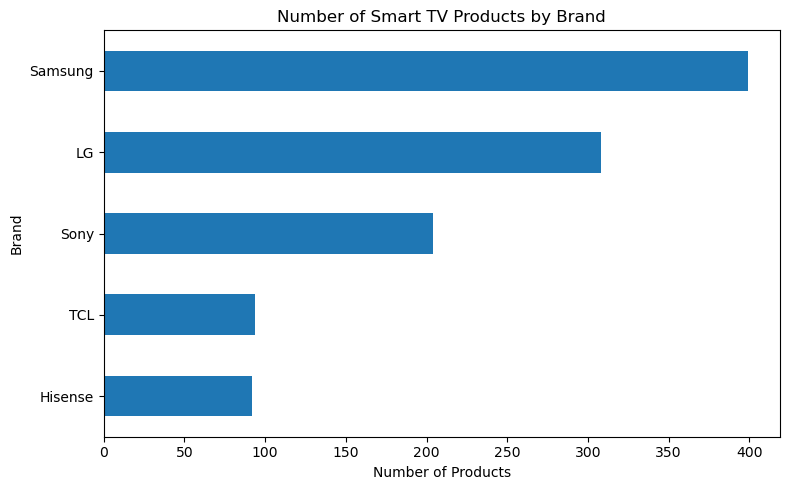

In [9]:
product_plot = (
    products["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

product_plot.plot(
    kind="barh"
)

plt.title(
    "Number of Smart TV Products by Brand"
)

plt.xlabel(
    "Number of Products"
)

plt.ylabel(
    "Brand"
)

# Number of Smart TV Products by Brand
plt.savefig(
    FIGURES_DIR / "03_products_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

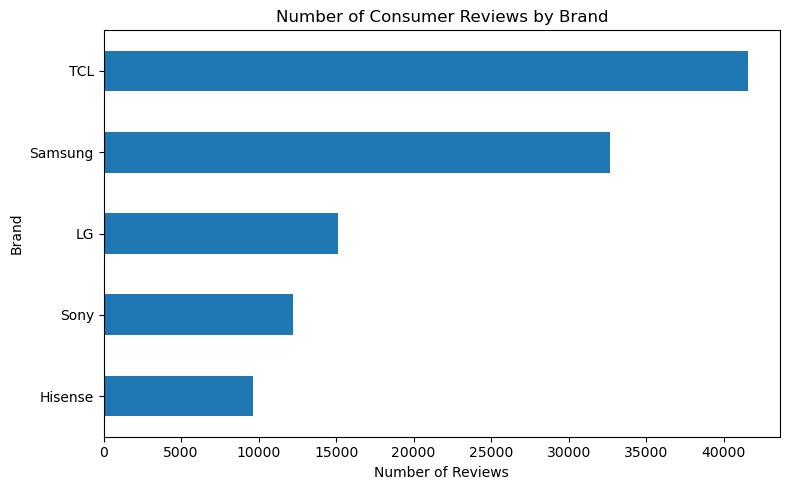

In [10]:
review_plot = (
    reviews["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

review_plot.plot(
    kind="barh"
)

plt.title(
    "Number of Consumer Reviews by Brand"
)

plt.xlabel(
    "Number of Reviews"
)

plt.ylabel(
    "Brand"
)

# Number of Consumer Reviews by Brand
plt.savefig(
    FIGURES_DIR / "03_reviews_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## 2. Customer Rating Distribution

In [11]:
rating_distribution = (
    reviews["rating"]
    .value_counts()
    .sort_index()
)

rating_percent = (
    reviews["rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

rating_summary = pd.DataFrame({
    "reviews": rating_distribution,
    "percent": rating_percent
})

display(
    rating_summary.round(2)
)

,reviews,percent
rating,,
1.0,19409,17.46
2.0,6553,5.89
3.0,7354,6.61
4.0,13077,11.76
5.0,64798,58.28


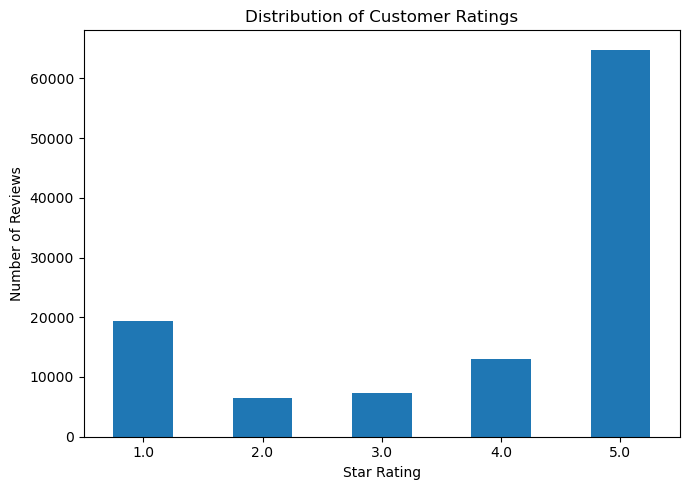

In [12]:
plt.figure(figsize=(7, 5))

rating_distribution.plot(
    kind="bar"
)

plt.title(
    "Distribution of Customer Ratings"
)

plt.xlabel(
    "Star Rating"
)

plt.ylabel(
    "Number of Reviews"
)

plt.xticks(rotation=0)

# Overall Customer Rating Distribution
plt.savefig(
    FIGURES_DIR / "03_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [13]:
brand_rating_dist = pd.crosstab(
    reviews["brand"],
    reviews["rating"],
    normalize="index"
) * 100

display(
    brand_rating_dist.round(2)
)

rating,1.0,2.0,3.0,4.0,5.0
brand,,,,,
Hisense,23.12,7.20,7.29,12.01,50.38
LG,13.93,5.18,6.59,12.90,61.40
Samsung,17.68,6.03,6.80,10.81,58.68
Sony,15.49,5.57,6.74,11.06,61.14
TCL,17.82,5.84,6.28,12.24,57.82


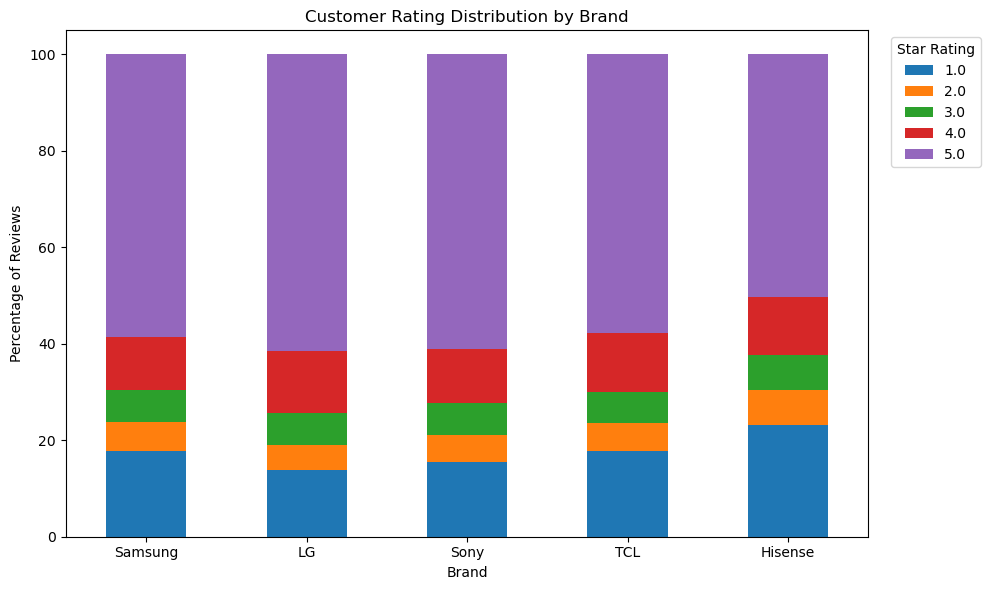

In [14]:
brand_order = [
    "Samsung",
    "LG",
    "Sony",
    "TCL",
    "Hisense"
]

brand_rating_dist.loc[
    brand_order
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Customer Rating Distribution by Brand"
)

plt.xlabel(
    "Brand"
)

plt.ylabel(
    "Percentage of Reviews"
)

plt.xticks(rotation=0)

plt.legend(
    title="Star Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Customer Rating Distribution by Brand
plt.savefig(
    FIGURES_DIR / "03_rating_distribution_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## 3. Review-Weighted vs. Product-Weighted Ratings

In [15]:
review_weighted_rating = (
    reviews
    .groupby("brand")["rating"]
    .mean()
    .rename("review_weighted_rating")
)

In [16]:
product_ratings = (
    reviews
    .groupby(
        ["brand", "parent_asin"]
    )["rating"]
    .mean()
    .reset_index(
        name="product_avg_rating"
    )
)

display(
    product_ratings.head()
)

,brand,parent_asin,product_avg_rating
0,Hisense,B00U0GZR34,3.627451
1,Hisense,B00XMUU4QK,4.013514
2,Hisense,B00ZGIJBXS,4.142857
3,Hisense,B00ZGIJDOU,4.333333
4,Hisense,B00ZGIJE9E,4.126214


In [17]:
product_weighted_rating = (
    product_ratings
    .groupby("brand")[
        "product_avg_rating"
    ]
    .mean()
    .rename(
        "product_weighted_rating"
    )
)

In [18]:
rating_comparison = pd.concat(
    [
        review_weighted_rating,
        product_weighted_rating
    ],
    axis=1
)

rating_comparison["difference"] = (
    rating_comparison[
        "review_weighted_rating"
    ]
    -
    rating_comparison[
        "product_weighted_rating"
    ]
)

display(
    rating_comparison.round(3)
)

,review_weighted_rating,product_weighted_rating,difference
brand,,,
Hisense,3.593,3.637,-0.043
LG,4.027,4.097,-0.070
Samsung,3.868,3.972,-0.104
Sony,3.968,4.157,-0.189
TCL,3.864,3.893,-0.029


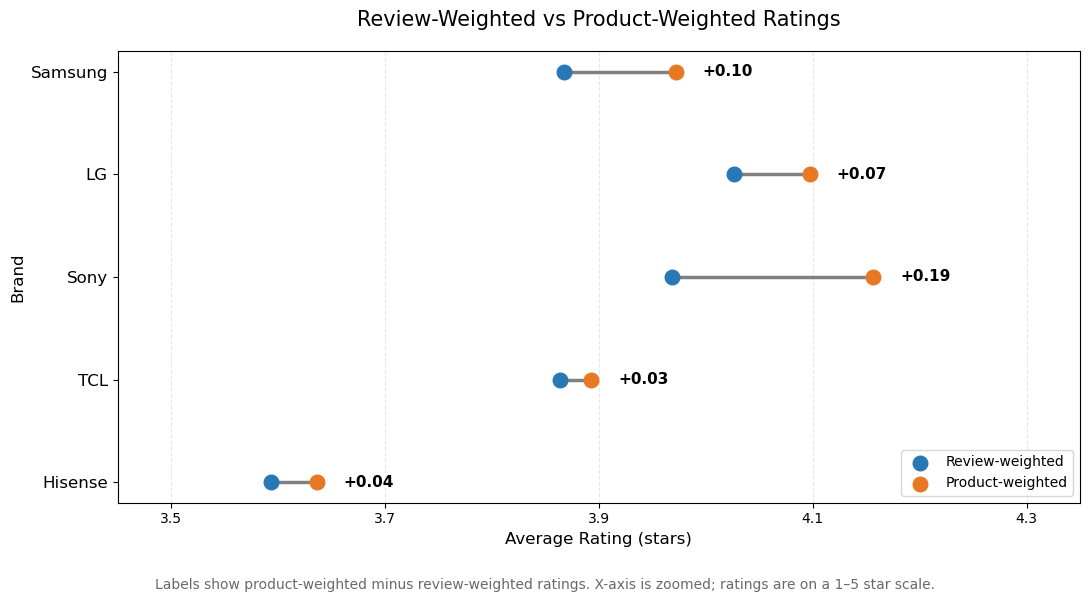

In [19]:
# Compare review-weighted and product-weighted ratings

plot_data = rating_comparison.loc[brand_order].copy()

review_values = plot_data["review_weighted_rating"]
product_values = plot_data["product_weighted_rating"]

# Difference: product-weighted minus review-weighted
differences = product_values - review_values

fig, ax = plt.subplots(figsize=(11, 6))

y_positions = range(len(plot_data))

# Connect the two ratings for each brand.
for i, brand in enumerate(plot_data.index):
    review_rating = review_values.loc[brand]
    product_rating = product_values.loc[brand]

    ax.plot(
        [review_rating, product_rating],
        [i, i],
        color="gray",
        linewidth=2.5,
        zorder=1
    )

    # Show the difference to the right of each pair.
    ax.text(
        max(review_rating, product_rating) + 0.025,
        i,
        f"+{differences.loc[brand]:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Review-weighted ratings
ax.scatter(
    review_values,
    list(y_positions),
    s=110,
    color="#2878B5",
    label="Review-weighted",
    zorder=3
)

# Product-weighted ratings
ax.scatter(
    product_values,
    list(y_positions),
    s=110,
    color="#E87924",
    label="Product-weighted",
    zorder=3
)

# Display brands in the original order.
ax.set_yticks(list(y_positions))
ax.set_yticklabels(plot_data.index, fontsize=12)
ax.invert_yaxis()

# Zoom into the relevant rating range.
ax.set_xlim(3.45, 4.35)

ax.set_xlabel("Average Rating (stars)", fontsize=12)
ax.set_ylabel("Brand", fontsize=12)

ax.set_title(
    "Review-Weighted vs Product-Weighted Ratings",
    fontsize=15,
    pad=18
)

# Make the x-axis easier to read.
ax.set_xticks([3.5, 3.7, 3.9, 4.1, 4.3])
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    loc="lower right",
    frameon=True
)

# Explain what the labels represent.
fig.text(
    0.5,
    0.01,
    "Labels show product-weighted minus review-weighted ratings. "
    "X-axis is zoomed; ratings are on a 1–5 star scale.",
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.055, 1, 1])

# Overwrite the existing figure used in the README.
plt.savefig(
    FIGURES_DIR / "03_weighted_rating_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Review Concentration

In [20]:
reviews_per_product = (
    reviews
    .groupby(
        ["brand", "parent_asin"]
    )
    .size()
    .reset_index(name="review_count")
)

In [21]:
reviews_per_product["brand_total_reviews"] = (
    reviews_per_product
    .groupby("brand")["review_count"]
    .transform("sum")
)

reviews_per_product["review_share"] = (
    reviews_per_product["review_count"]
    / reviews_per_product["brand_total_reviews"]
)

In [22]:
def concentration_summary(group):
    counts = (
        group["review_count"]
        .sort_values(ascending=False)
    )

    total = counts.sum()

    return pd.Series({
        "top_1_share": counts.iloc[:1].sum() / total * 100,
        "top_5_share": counts.iloc[:5].sum() / total * 100,
        "top_10_share": counts.iloc[:10].sum() / total * 100
    })


brand_concentration = (
    reviews_per_product
    .groupby("brand")
    .apply(
        concentration_summary,
        include_groups=False
    )
)

display(
    brand_concentration.round(2)
)

,top_1_share,top_5_share,top_10_share
brand,,,
Hisense,6.58,28.87,49.92
LG,8.06,26.93,41.57
Samsung,11.21,37.14,49.81
Sony,7.42,26.39,42.71
TCL,15.08,67.71,83.80


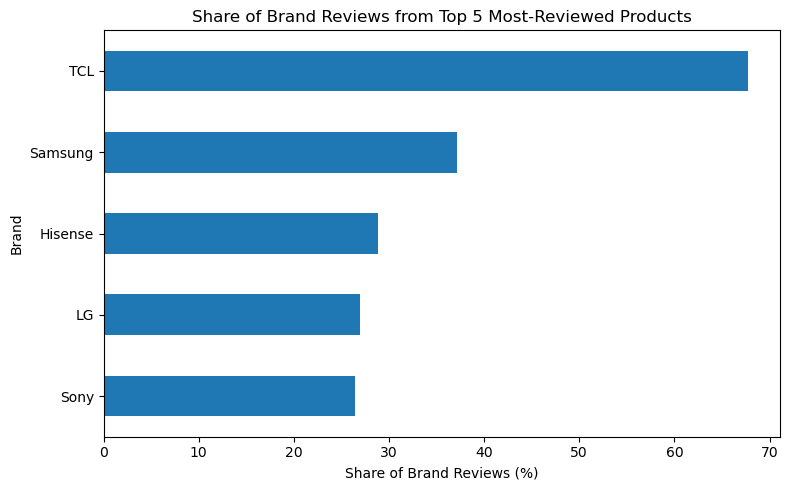

In [23]:
top5_plot = (
    brand_concentration["top_5_share"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

top5_plot.plot(
    kind="barh"
)

plt.title(
    "Share of Brand Reviews from Top 5 Most-Reviewed Products"
)

plt.xlabel(
    "Share of Brand Reviews (%)"
)

plt.ylabel(
    "Brand"
)

# Review Concentration
plt.savefig(
    FIGURES_DIR / "03_review_concentration_top5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


## 5. Product Attribute Extraction

In [24]:
import re

In [25]:
def extract_screen_size(title):
    if not isinstance(title, str):
        return np.nan

    patterns = [
        # 55-inch, 55 Inch
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*inch(?:es)?\b',

        # 55", 55”
        r'(\d{2,3}(?:\.\d+)?)\s*["”]',

        # 55-in, 55 in
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*in\b',

        # 55-Class, 55 Class
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*class\b',

        # 54.6 2160p / 65 4K / 75 4K
        r'(\d{2,3}(?:\.\d+)?)\s+(?=4K|8K|2160p|1080p|720p)'
    ]

    for pattern in patterns:
        match = re.search(
            pattern,
            title,
            flags=re.IGNORECASE
        )

        if match:
            size = float(match.group(1))

            if 15 <= size <= 120:
                return size

    return np.nan


products["screen_size"] = (
    products["title"]
    .apply(extract_screen_size)
)

In [26]:
print(
    "Screen size coverage:",
    round(
        products["screen_size"]
        .notna()
        .mean()
        * 100,
        2
    ),
    "%"
)

display(
    products["screen_size"]
    .describe()
)

print(
    "Missing:",
    products["screen_size"].isna().sum()
)

Screen size coverage: 98.72 %


count    1083.000000
mean       58.394090
std        14.748825
min        22.000000
25%        49.000000
50%        55.000000
75%        65.000000
max       120.000000
Name: screen_size, dtype: float64

Missing: 14


In [27]:
display(
    products["screen_size"]
    .value_counts()
    .head(20)
)

screen_size
65.0     253
55.0     219
75.0     102
43.0      96
50.0      77
32.0      63
49.0      42
85.0      39
40.0      28
77.0      22
70.0      21
48.0      19
86.0      15
60.0      14
58.0      12
24.0      10
100.0      6
82.0       6
98.0       4
42.0       4
Name: count, dtype: int64

In [28]:
def extract_resolution(title):
    if not isinstance(title, str):
        return "Unknown"

    text = title.lower()

    if re.search(r'\b8k\b|4320p', text):
        return "8K"

    if re.search(
        r'\b4k\b|2160p|ultra\s*hd|\buhd\b',
        text
    ):
        return "4K"

    if re.search(
        r'1080p|full\s*hd|\bfhd\b',
        text
    ):
        return "1080p"

    if re.search(
        r'720p|\bhd\b',
        text
    ):
        return "720p"

    return "Unknown"


products["resolution"] = (
    products["title"]
    .apply(extract_resolution)
)

In [29]:
resolution_summary = pd.DataFrame({
    "products": products["resolution"].value_counts(),
    "percent": products["resolution"].value_counts(
        normalize=True
    ) * 100
})

display(
    resolution_summary.round(2)
)

,products,percent
resolution,,
4K,912,83.14
1080p,84,7.66
720p,45,4.10
Unknown,31,2.83
8K,25,2.28


In [30]:
resolution_by_brand = pd.crosstab(
    products["brand"],
    products["resolution"],
    normalize="index"
) * 100

display(
    resolution_by_brand.round(2)
)

resolution,1080p,4K,720p,8K,Unknown
brand,,,,,
Hisense,16.30,70.65,5.43,1.09,6.52
LG,7.14,82.47,6.17,0.65,3.57
Samsung,5.76,87.47,1.50,3.76,1.50
Sony,2.45,92.65,0.98,2.45,1.47
TCL,20.21,58.51,13.83,2.13,5.32


In [31]:
def classify_display_type(text):
    if not isinstance(text, str):
        return "Unknown"

    text = text.lower()

    if re.search(r'mini[\s-]?led', text):
        return "Mini-LED"

    if re.search(r'\boled\b', text):
        return "OLED"

    if re.search(r'\bqled\b|quantum\s+dot', text):
        return "QLED"

    if re.search(r'nanocell', text):
        return "NanoCell"

    if re.search(
        r'\bled\b|led[\s-]?lcd|\blcd\b',
        text
    ):
        return "LED/LCD"

    return "Unknown"

In [32]:
def extract_display_type(row):
    # Primary source: product title
    result = classify_display_type(
        row["title"]
    )

    if result != "Unknown":
        return result

    # Fallback source: product features
    features = row["features"]

    if isinstance(features, (list, np.ndarray)):
        features_text = " ".join(
            str(x) for x in features
        )
    else:
        features_text = str(features)

    return classify_display_type(
        features_text
    )


products["display_type"] = (
    products.apply(
        extract_display_type,
        axis=1
    )
)

In [33]:
display_type_summary = pd.DataFrame({
    "products":
        products["display_type"]
        .value_counts(),

    "percent":
        products["display_type"]
        .value_counts(normalize=True)
        * 100
})

display(
    display_type_summary.round(2)
)

,products,percent
display_type,,
LED/LCD,485,44.21
QLED,227,20.69
Unknown,176,16.04
OLED,160,14.59
Mini-LED,25,2.28
NanoCell,24,2.19


In [34]:
display_by_brand = pd.crosstab(
    products["brand"],
    products["display_type"],
    normalize="index"
) * 100

display(
    display_by_brand.round(2)
)

display_type,LED/LCD,Mini-LED,NanoCell,OLED,QLED,Unknown
brand,,,,,,
Hisense,38.04,3.26,0.00,0.00,15.22,43.48
LG,41.56,0.65,7.79,28.90,0.32,20.78
Samsung,35.84,2.01,0.00,2.76,49.62,9.77
Sony,62.75,2.45,0.00,29.41,0.00,5.39
TCL,54.26,7.45,0.00,0.00,14.89,23.40


In [35]:
products["title_display_type"] = (
    products["title"]
    .apply(classify_display_type)
)

resolved_by_features = (
    (products["title_display_type"] == "Unknown")
    &
    (products["display_type"] != "Unknown")
)

print(
    "Resolved using features:",
    resolved_by_features.sum()
)

print(
    "Final Unknown:",
    (products["display_type"] == "Unknown").sum()
)

print(
    "Final coverage:",
    round(
        (
            products["display_type"]
            != "Unknown"
        ).mean() * 100,
        2
    ),
    "%"
)

Resolved using features: 53
Final Unknown: 176
Final coverage: 83.96 %


In [36]:
display(
    products.loc[
        resolved_by_features,
        [
            "brand",
            "title",
            "features",
            "display_type"
        ]
    ].sample(
        min(
            20,
            resolved_by_features.sum()
        ),
        random_state=42
    )
)

,brand,title,features,display_type
340,LG,LG 28LM430B-PU - 28-inch Full HD TV (2017 Model),"[28LM430B-PU 28"" Class HD LED TV - Remote Controller - Stand - Power Cord - LG 1 Year Limited Warranty, 28"" Wide Viewing Angle HD TV, Dual HDMI, 5...",LED/LCD
747,LG,"LG 49UK6300 49"" UK6300 Smart 4K UHD TV with Wall Mount + Cleaning Kit (49UK6300PUE)","[LG USA AUTHORIZED - Includes Full LG USA WARRANTY, LG 49"" UK6300 Class 4K HDR Smart LED AI UHD TV w/ThinQ, LG Sound Sync, IN THE BOX: Standard Re...",LED/LCD
906,LG,"LG 65NANO81ANA 65"" Nano 8 4K UHD TV AI ThinQ (2020) with Deco Gear Soundbar Bundle","[LG 65NANO81ANA 65"" Nano 8 Series Class 4K Smart UHD NanoCell TV with AI ThinQ (2020 Mode, LG NanoCell TV delivers enhanced 4K movies, sports and ...",NanoCell
225,LG,"LG 86-Inch Class QNED80 Series Alexa Built-in 4K Smart TV, 120Hz Refresh Rate, AI-Powered 4K, HDR Pro, WiSA Ready, Cloud Gaming (86QNED80UQA, 2022)","[VOICE CONTROL: Use your voice to control your TV and connected devices with built-in support for Google Assistant, Amazon Alexa, Apple AirPlay, H...",QLED
778,Hisense,Hisense 65H10B2 Curved 65-Inch 4K Smart ULED TV (2015 Model),"[Refresh Rate: 120 Hz (Native), Backlight: LED, Dimensions (W x H x D): TV without stand: 56.9'' x 33"" x 6'', TV with stand: 56.9'' x 34.5'' x 11....",LED/LCD
134,LG,LG 75SK8070PUA 75 4K AI UHD TV w/ThinQ + Wireless Keyboard + Wall Bracket Bundle,"[alpha 7 Intelligent Processor: Enjoy a more lifelike picture with superior depth, sharpness, and remarkably accurate color. The alpha 7 Intellige...",LED/LCD
323,Samsung,SAMSUNG UN55TU8300 55-inch HDR 4K UHD Smart Curved TV with Deco Home Soundbar Bundle,"[SAMSUNG USA AUTHORIZED - Includes Full SAMSUNG USA WARRANTY, Samsung UN55TU8300 55"" HDR 4K UHD Smart Curved TV -, Crystal Processing 4K | Multipl...",LED/LCD
1018,LG,"LG 43UP8000PUA 43 Inch 4K UHD Smart webOS TV Bundle with Deco Home 60W 2.0 Channel Soundbar, 37""-100"" TV Wall Mount Bracket Bundle and 6-Outlet Su...","[LG USA AUTHORIZED - Includes Full LG USA WARRANTY, LG 43UP8000PUA 43 Inch 4K UHD Smart webOS TV, Real 4K Display | Quad Core Processor 4K | TruMo...",LED/LCD
70,Hisense,"Hisense 50-Inch Class R6 Series Dolby Vision HDR 4K UHD Roku Smart TV with Alexa Compatibility (50R6G, 2021 Model), Black","[4K UltraHD delivers more than four times the resolution of a regular 1080p highdefinition screen. Along with over 8.3 million pixels, inside you'...",LED/LCD
572,LG,LG OLED48A1PUA 48 Inch A1 Series 4K HDR Smart TV with AI ThinQ Bundle with Premium 2 YR CPS Enhanced Protection Pack,"[LG USA AUTHORIZED - Includes 2 Year Extended Protection Plan in ADDITION to the Included FULL Manufacturer Protection, Experience the power of OL...",OLED


In [37]:
product_performance = (
    reviews
    .groupby("parent_asin")
    .agg(
        product_avg_rating=("rating", "mean"),
        review_count=("rating", "size")
    )
    .reset_index()
)

product_analysis = products.merge(
    product_performance,
    on="parent_asin",
    how="left"
)

print("Products:", len(product_analysis))
print(
    "Products with reviews:",
    product_analysis["product_avg_rating"]
    .notna()
    .sum()
)

display(
    product_analysis[
        [
            "brand",
            "title",
            "screen_size",
            "resolution",
            "display_type",
            "product_avg_rating",
            "review_count"
        ]
    ].head()
)

Products: 1097
Products with reviews: 1096


,brand,title,screen_size,resolution,display_type,product_avg_rating,review_count
0,Samsung,"SAMSUNG QN65Q60TA 65"" Q60T QLED 4K UHD HDR Smart TV Bundle with Deco Gear Home Theater Soundbar with Subwoofer and Complete Wall Mount Setup and A...",65.0,4K,QLED,4.000000,7.0
1,LG,LG Electronics OLED55B7A 55-Inch 4K Ultra HD Smart OLED TV (2017 Model),55.0,4K,OLED,3.854369,206.0
2,Samsung,"Samsung Q70 Series 55-Inch Smart TV, Flat QLED 4K UHD HDR - 2019 Model",55.0,4K,QLED,3.960417,480.0
3,Samsung,SAMSUNG UN75RU7100FXZA Flat 75-Inch 4K UHD 7 Series Ultra HD Smart TV with HDR and Alexa Compatibility (2019 Model),75.0,4K,Unknown,4.156031,2993.0
4,LG,"LG 86UM8070 86-Inch, 4K LED UHD Smart TV (2019)",86.0,4K,LED/LCD,4.294964,139.0


In [38]:
def categorize_screen_size(size):
    if pd.isna(size):
        return "Unknown"

    if size < 40:
        return "Under 40"

    if size < 50:
        return "40–49"

    if size < 60:
        return "50–59"

    if size < 70:
        return "60–69"

    return "70+"


product_analysis["size_segment"] = (
    product_analysis["screen_size"]
    .apply(categorize_screen_size)
)

In [39]:
size_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("size_segment")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
)

size_order = [
    "Under 40",
    "40–49",
    "50–59",
    "60–69",
    "70+",
    "Unknown"
]

size_satisfaction = (
    size_satisfaction
    .reindex(size_order)
    .dropna(how="all")
)

display(
    size_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
size_segment,,,,
Under 40,83,3.82,3.98,258.05
40–49,196,3.99,4.00,85.58
50–59,309,4.00,4.00,109.86
60–69,267,4.00,4.12,69.73
70+,227,4.08,4.14,87.36
Unknown,14,4.35,4.51,43.14


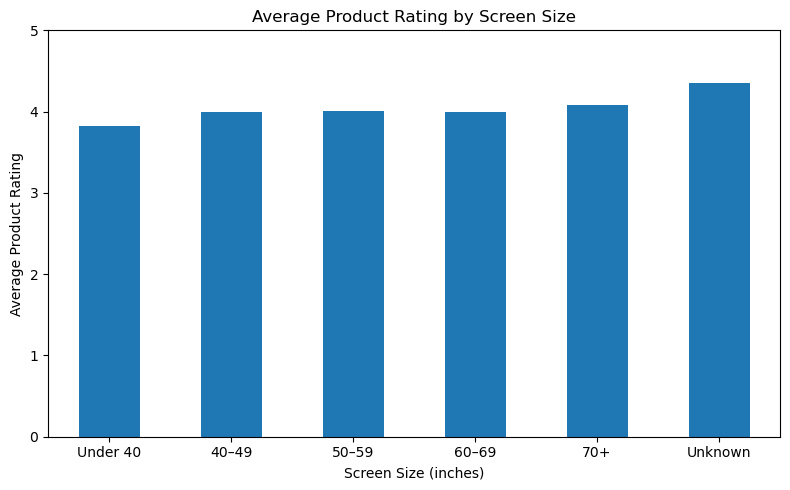

In [40]:
plt.figure(figsize=(8, 5))

size_satisfaction["avg_rating"].plot(
    kind="bar"
)

plt.title(
    "Average Product Rating by Screen Size"
)

plt.xlabel(
    "Screen Size (inches)"
)

plt.ylabel(
    "Average Product Rating"
)

plt.ylim(0, 5)

plt.xticks(rotation=0)

# Rating by Screen Size
plt.savefig(
    FIGURES_DIR / "03_rating_by_screen_size.png",
    dpi=300,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()


In [41]:
resolution_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("resolution")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
    .sort_values(
        "avg_rating",
        ascending=False
    )
)

display(
    resolution_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
resolution,,,,
4K,911,4.04,4.12,80.20
1080p,84,3.92,3.91,168.74
720p,45,3.92,4.02,370.64
8K,25,3.70,3.67,20.32
Unknown,31,3.62,3.62,218.35


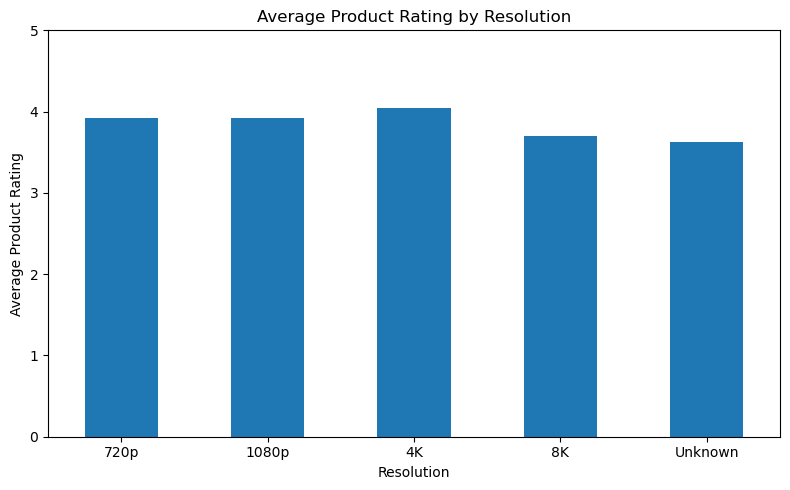

In [42]:
resolution_order = [
    "720p",
    "1080p",
    "4K",
    "8K",
    "Unknown"
]

resolution_plot = (
    resolution_satisfaction
    .reindex(resolution_order)
    .dropna()
)

plt.figure(figsize=(8, 5))

resolution_plot["avg_rating"].plot(
    kind="bar"
)

plt.title(
    "Average Product Rating by Resolution"
)

plt.xlabel(
    "Resolution"
)

plt.ylabel(
    "Average Product Rating"
)

plt.ylim(0, 5)

plt.xticks(rotation=0)

# Rating by Resolution
plt.savefig(
    FIGURES_DIR / "03_rating_by_resolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [43]:
display_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("display_type")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
    .sort_values(
        "avg_rating",
        ascending=False
    )
)

display(
    display_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
display_type,,,,
OLED,159,4.29,4.50,43.77
NanoCell,24,4.26,4.37,34.46
Mini-LED,25,4.01,3.94,101.48
LED/LCD,485,3.98,4.01,123.39
QLED,227,3.95,4.00,59.38
Unknown,176,3.86,4.00,156.49


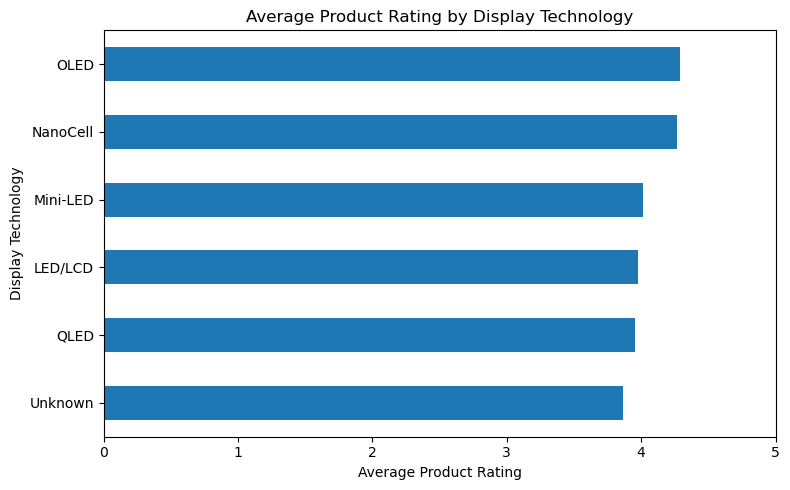

In [44]:
plt.figure(figsize=(8, 5))

display_satisfaction[
    "avg_rating"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Average Product Rating by Display Technology"
)

plt.xlabel(
    "Average Product Rating"
)

plt.ylabel(
    "Display Technology"
)

plt.xlim(0, 5)

# Rating by Display Technology
plt.savefig(
    FIGURES_DIR / "03_rating_by_display_technology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [45]:
display_brand_tech = (
    product_analysis[
        product_analysis["display_type"]
        != "Unknown"
    ]
    .pivot_table(
        index="brand",
        columns="display_type",
        values="product_avg_rating",
        aggfunc=["mean", "count"]
    )
)

display(
    display_brand_tech.round(2)
)

mean                                 count                    \
display_type LED/LCD Mini-LED NanoCell  OLED  QLED LED/LCD Mini-LED NanoCell   
brand                                                                          
Hisense         3.59     4.31      NaN   NaN  3.79    35.0      3.0      NaN   
LG              4.05     3.58     4.26  4.24  3.90   128.0      2.0     24.0   
Samsung         3.96     3.75      NaN  4.14  3.95   143.0      8.0      NaN   
Sony            4.06     4.67      NaN  4.38   NaN   128.0      5.0      NaN   
TCL             3.90     3.85      NaN   NaN  4.11    51.0      7.0      NaN   

                           
display_type  OLED   QLED  
brand                      
Hisense        NaN   14.0  
LG            89.0    1.0  
Samsung       11.0  198.0  
Sony          59.0    NaN  
TCL            NaN   14.0

In [46]:
brand_display_summary = (
    product_analysis[
        (product_analysis["display_type"] != "Unknown")
        &
        (product_analysis["product_avg_rating"].notna())
    ]
    .groupby(
        ["brand", "display_type"]
    )
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean")
    )
    .reset_index()
)

display(
    brand_display_summary
    .sort_values(
        ["brand", "products"],
        ascending=[True, False]
    )
    .round(2)
)

,brand,display_type,products,avg_rating
0,Hisense,LED/LCD,35,3.59
2,Hisense,QLED,14,3.79
1,Hisense,Mini-LED,3,4.31
3,LG,LED/LCD,128,4.05
6,LG,OLED,89,4.24
5,LG,NanoCell,24,4.26
4,LG,Mini-LED,2,3.58
7,LG,QLED,1,3.90
11,Samsung,QLED,198,3.95
8,Samsung,LED/LCD,143,3.96


## 6. Interpretation and Next Steps

The exploratory analysis reveals several patterns in the 2015–2023 Smart TV dataset:

* **Rating aggregation matters.** Review-weighted ratings are lower than product-weighted ratings for all five brands. For example, Sony's average is 3.968 when weighted by reviews versus 4.157 when each reviewed product receives equal weight.
* **Review volume is concentrated.** TCL's five most-reviewed products account for 67.71% of its reviews, meaning its review-weighted results are particularly influenced by a small number of products.
* **Product attributes show descriptive differences.** OLED products average 4.29 stars, compared with 3.98 for LED/LCD products. Screen-size and resolution groups also differ, but these comparisons do not isolate the effects of individual specifications.

These findings are descriptive associations, not causal effects. Differences in brand composition, product popularity, review volume, and imperfect attribute extraction may influence the observed patterns. One product has no matched reviews and is excluded from product-rating comparisons.

The next notebook examines review text to understand which aspects of the ownership experience consumers discuss alongside higher and lower ratings.


In [47]:
products_final = products.drop(
    columns=["title_display_type"],
    errors="ignore"
).copy()

products_final.to_parquet(
    "../data/tv_products_analysis.parquet",
    index=False
)

reviews.to_parquet(
    "../data/tv_reviews_analysis.parquet",
    index=False
)

print("Products saved:", products_final.shape)
print("Reviews saved:", reviews.shape)

Products saved: (1097, 19)
Reviews saved: (111191, 14)


In [48]:
product_analysis.to_parquet(
    "../data/tv_product_performance.parquet",
    index=False
)

print("Product performance saved:", product_analysis.shape)

Product performance saved: (1097, 23)
